In [244]:
import multiprocessing as mp
import os
import pickle
import random
import re
import sys
from timeit import default_timer as timer

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tmap as tm
from faerun import Faerun
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem, Descriptors
from tqdm import tqdm
from tqdm.auto import trange

sys.path.append("/workspace/HDD1/user/ohto_2/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/src")

from util import *

RDLogger.DisableLog('rdApp.*')

import glob
import os
import pickle
import sys
import warnings
from datetime import datetime

import pandas as pd
import xgboost as xgb
from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
from sklearn.metrics import (accuracy_score, classification_report, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score,
                             roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

In [245]:
# df = pd.read_csv('../../../../github/patent_time_split/data/processed/tdc/Tox/4_hERG_Karim_date.tsv', sep='\t')

test_name = "tox21"
df = pd.read_csv(f"/workspace/HDD1/user/ohto_2/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/data/processed/moleculenet/moleculenet_patentdate/{test_name}/date_dataset.tsv", sep="\t", header=None)

In [246]:
def compute_ecfp(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    return None

In [247]:
smiles = []
years = []
ecfps = []
# toxs = []

for i in trange(len(df)):
    smiles.append(df.iloc[i,0])
    years.append(int(df.iloc[i,1]))
    ecfps.append(compute_ecfp(df.iloc[i,0]))
    # toxs.append(df.iloc[i,1])

  0%|          | 0/6178 [00:00<?, ?it/s]

In [248]:
enc = tm.Minhash(128)
lf = tm.LSHForest(128)

d = 2048
n = len(smiles)

data = []
start = timer()
for x in trange(n):
    data.append(tm.VectorUchar(np.array(ecfps[x])))
print(f"Generating the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.batch_add(enc.batch_from_binary_array(data))
print(f"Adding the data took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
lf.index()
print(f"Indexing took {(timer() - start) * 1000}ms.", flush=True)

start = timer()
knng_from = tm.VectorUint()
knng_to = tm.VectorUint()
knng_weight = tm.VectorFloat()

_ = lf.get_knn_graph(knng_from, knng_to, knng_weight, 10)
print(f"make knn graph {(timer() - start) * 1000}ms.", flush=True)

  0%|          | 0/6178 [00:00<?, ?it/s]

Generating the data took 20786.082790000364ms.
Adding the data took 13106.28872498637ms.
Indexing took 393.29057198483497ms.
make knn graph 3198.7222880125046ms.


1966 2023 58


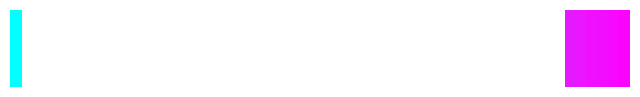

In [249]:
labels = years
num_colors = min(labels)
total_colors = max(labels) - min(labels) + 1 

print(min(labels), max(labels), total_colors)

base_cmap = plt.get_cmap("cool")
colors = [base_cmap(i / total_colors) for i in range(total_colors)]

black_section = [(0, 0, 0, 0)] * num_colors  # 1973個の黒
new_colors = black_section + colors  # 1973個の黒 + 残りの色

MY_CM = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

colors_section = new_colors[num_colors:]  

for i in range(1, len(colors_section)-6):
    colors_section[i] = (0, 0, 0, 0)

new_colors[num_colors:] = colors_section

MY_CM_SELECTED = LinearSegmentedColormap.from_list("my_map_black", colors_section, N=len(colors_section))
MY_CM_3 = LinearSegmentedColormap.from_list("my_map_black", new_colors, N=len(new_colors))

gradient = np.linspace(0, 1, 256).reshape(1, -1)
plt.figure(figsize=(8, 1))
plt.imshow(gradient, aspect="auto", cmap=MY_CM_SELECTED)
plt.axis("off")
plt.show()

In [250]:
custom_cmap = ListedColormap(
    ["#ffffff", "#ff0000"],
    name="custom",
)

custom_cmap_4 = ListedColormap(
    ["#ffffff", "#ff0000", "#00bfff", "#ffb6c1"],  # 白 → 赤 → 明るい青 → 明るいピンク
    name="bright_contrast"
)

custom_cmap_6 = ListedColormap(
    ["#ffffff", "#ffff00", "#ffa500", "#ff0000", "#8b0000", "#000000"],
    name="dramatic6"
)

In [251]:
# X = ecfps
# y = toxs

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)
# le = LabelEncoder()
# y_train = le.fit_transform(y_train)
# model = xgb.XGBClassifier()
# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)
# r2 = r2_score(y_test, y_pred)
# mse = mean_squared_error(y_test, y_pred)
# mae = mean_absolute_error(y_test, y_pred)
# result = ["time", r2, mse, mae, sum(y)/len(y), sum(y_train)/len(y_train), sum(y_test)/len(y_test)]

In [252]:
# original_y_list = list(y)
# train_y_list = list(y_train) 
# test_y_list = list(y_pred)  

# tested_y_list = []
# for pred_val in y_test:
#     if pred_val >= 0.5:
#         tested_y_list.append(3)
#     else:
#         tested_y_list.append(2)
# tested_y_list = train_y_list + tested_y_list

# predicted_y_list = []
# for pred_val in y_pred:
#     if pred_val >= 0.5:
#         predicted_y_list.append(3)
#     else:
#         predicted_y_list.append(2)
# predicted_y_list = train_y_list + predicted_y_list

# result_labels = []
# for true_val, pred_val in zip(y_test, y_pred):
#     pred_val_rounded = round(pred_val) 
#     if true_val == pred_val_rounded and true_val == 1:
#         result_labels.append(3)
#     elif true_val == pred_val_rounded and true_val == 0:
#         result_labels.append(2)
#     elif pred_val_rounded == 0:
#         result_labels.append(4) 
#     else:
#         result_labels.append(5) 
# result_labels = train_y_list + result_labels

In [253]:
# y_prob = model.predict_proba(X_test)
# auroc = roc_auc_score(y_test, y_prob[:, 1])
# result = ["time", r2, mse, mae, sum(y)/len(y), sum(y_train)/len(y_train), sum(y_test)/len(y_test), auroc]
# print(f"auroc: {auroc}")

In [254]:
x, y, s, t, _ = tm.layout_from_lsh_forest(lf)

faerun = Faerun(clear_color="#111111", view="front", coords=False)

faerun.add_scatter(
    f"{test_name}",
    {"x": x, "y": y, "c": [labels, labels], "labels": smiles},
    colormap=[MY_CM, MY_CM_3],
    shader="smoothCircle",
    series_title=["Year", "Year"],
    point_scale=2.5,
    max_point_size=30,
    has_legend=True,
    categorical=True,
)
faerun.add_tree(
    f"{test_name}", {"from": s, "to": t}, point_helper=f"{test_name}", color="#666666"
)

faerun.plot(f"{test_name}", template="smiles")

/workspace/HDD1/user/ohto_2/1-project/2-tox_pred/2-patent_date_split/github/patent_time_split/notebook/experiment/tox21.html

In [255]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

mol_weights = []
for i in range(len(df)):
    smiles = df.iloc[i,0]
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        mol_weights.append(Descriptors.MolWt(mol))
    else:
        mol_weights.append(None)

tpsa = []
for i in range(len(df)):
    smiles = df.iloc[i,0]
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        tpsa.append(Descriptors.TPSA(mol))
    else:
        tpsa.append(None)

logp = []
for i in range(len(df)):
    smiles = df.iloc[i,0]
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        logp.append(Descriptors.MolLogP(mol))
    else:
        logp.append(None)

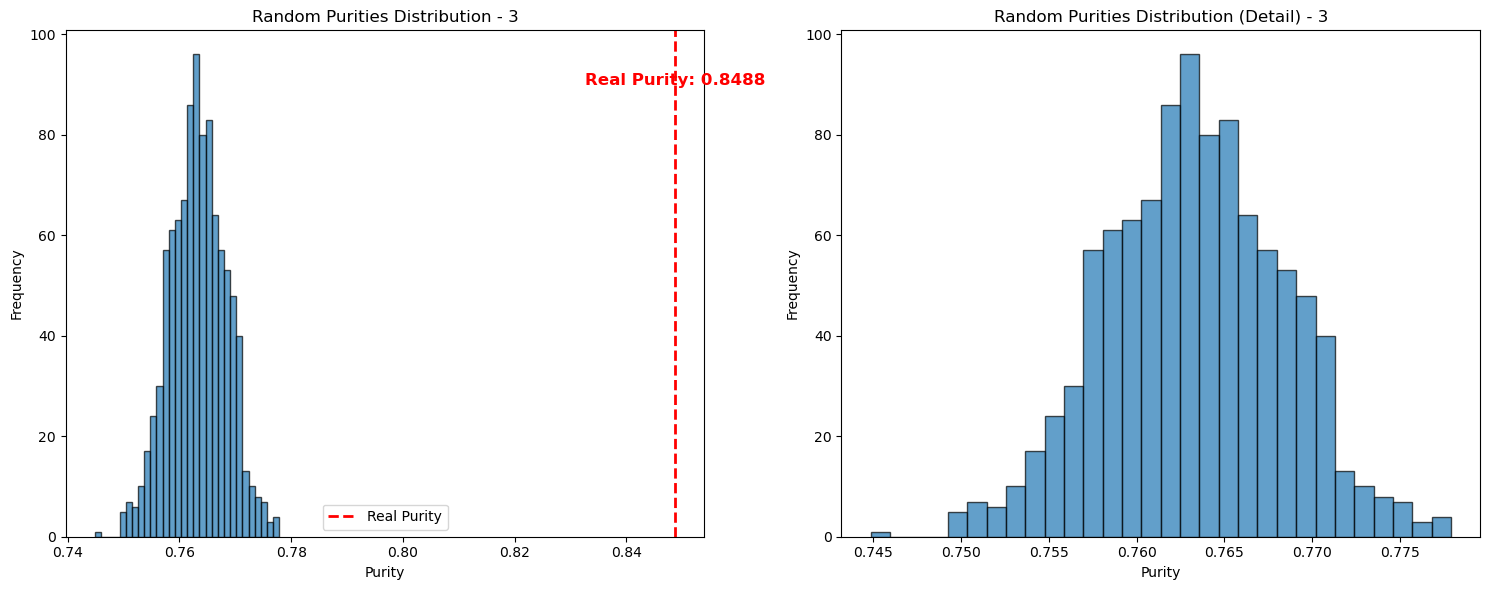

<built-in function id> 0.0 3


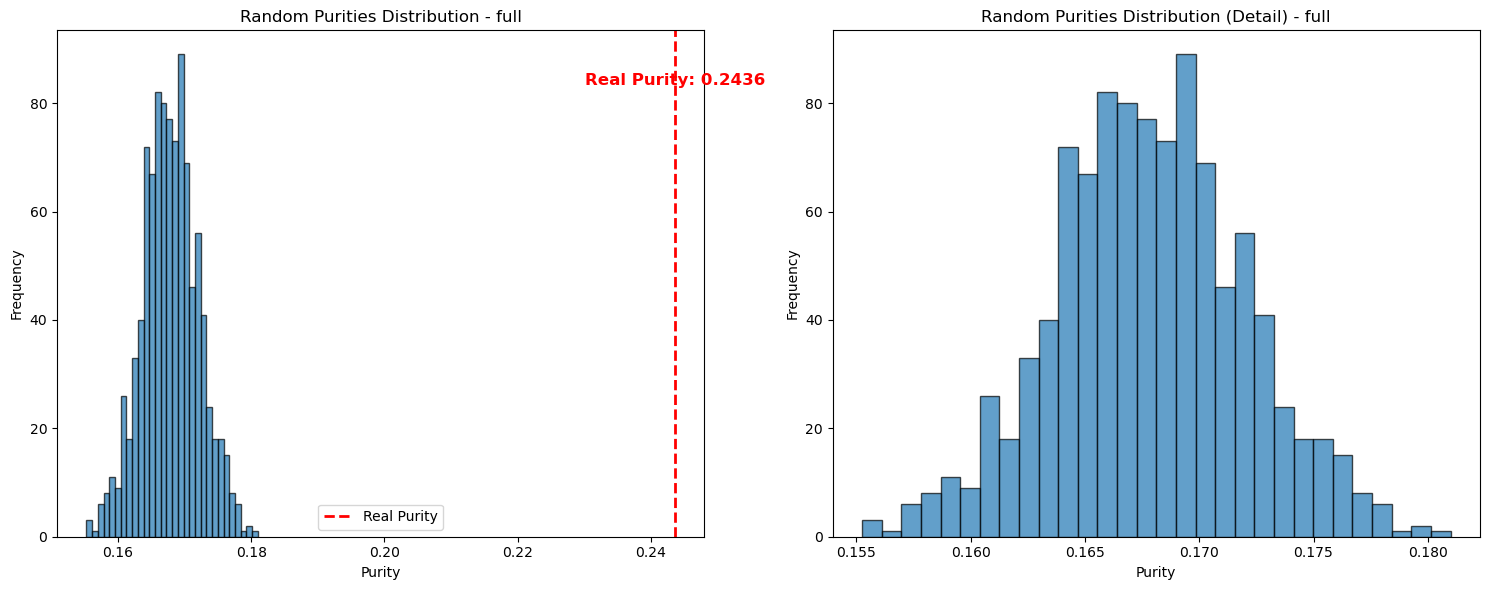

<built-in function id> 0.0 full


In [256]:
num_permutations = 1000
scores = []
p_values_3 = []
p_values_full = []

def lsh_forest_purity(s, t, labels):
    matches = (labels[s] == labels[t]) 
    purity = np.sum(matches) / len(matches)
    return purity

output_dir = f"../../data/result/tmap/tdc/{test_name}"
os.makedirs(output_dir, exist_ok=True)

# labels_full = [1980 if year <= 1980 else 2023 if year >= 2023 else year for year in years]
labels_3 = [0 if year <= 1990 else 2 if year >= 2023 else 1 for year in years]
labels_full = np.array(years)
labels_3, labels_full = np.array(labels_3), np.array(labels_full)

for labels, label_type in [(labels_3, "3"), (labels_full, "full")]:
    lsh_purity_real = lsh_forest_purity(s, t, labels)
    random_purities = []

    for _ in range(num_permutations):
        shuffled_labels = np.random.permutation(labels)
        random_purity = lsh_forest_purity(s, t, shuffled_labels)
        random_purities.append(random_purity)

    random_purities = np.array(random_purities)
    fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 
    
    axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Purity')
    axs[0].set_title(f"Random Purities Distribution - {label_type}")
    axs[0].set_xlabel("Purity")
    axs[0].set_ylabel("Frequency")
    axs[0].legend()
    axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Purity: {lsh_purity_real:.4f}', 
                color='red', ha='center', va='center', fontsize=12, fontweight='bold')

    axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
    axs[1].set_title(f"Random Purities Distribution (Detail) - {label_type}")
    axs[1].set_xlabel("Purity")
    axs[1].set_ylabel("Frequency")

    plt.tight_layout() 
    plt.savefig(f"{output_dir}/random_purities_{label_type}.png")
    plt.show()

    p_value = np.mean(random_purities >= lsh_purity_real)
    print(id, p_value, label_type)

    scores.append([id, p_value, label_type])

    if label_type == "3":
        p_values_3.append(p_value)
    else:
        p_values_full.append(p_value)

In [257]:
import collections
counter_year = collections.Counter(years)
print("Year distribution:", counter_year)

Year distribution: Counter({1976: 2375, 1975: 407, 1977: 380, 1973: 376, 1978: 246, 1974: 212, 1980: 196, 1979: 195, 1981: 171, 1982: 119, 1985: 102, 1983: 93, 1984: 81, 1989: 81, 1988: 80, 1990: 73, 2001: 73, 1986: 72, 1987: 68, 1991: 66, 1997: 62, 1995: 58, 1992: 55, 1993: 45, 1994: 45, 2007: 40, 1998: 38, 2000: 36, 1996: 35, 2003: 34, 2005: 30, 2002: 28, 1999: 26, 2004: 25, 2006: 24, 2008: 21, 2010: 18, 2009: 15, 2011: 13, 2014: 12, 2013: 11, 2020: 7, 2015: 7, 2018: 7, 2012: 6, 2017: 4, 2016: 2, 1966: 2, 2021: 2, 2023: 2, 1972: 1, 2019: 1})


In [ ]:
import collections
counter_year = collections.Counter(years)
counter_year_keys = sorted(list(counter_year.keys()))

In [259]:
count = []
for key in counter_year_keys:
    count.append(counter_year[key])

In [260]:
mols = []
for i in range(len(df)):
    smiles = df.iloc[i,0]
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        mols.append(mol)
    else:
        mols.append(None)

In [261]:
smiles = df.iloc[:, 0].tolist()
sorted_tpsa = sorted(tpsa)
sorted_tpsa_index = sorted(range(len(tpsa)), key=lambda k: tpsa[k])
sorted_smiles = [smiles[i] for i in sorted_tpsa_index]
sorted_mols = [mols[i] for i in sorted_tpsa_index]

In [262]:
tpsa_label = [0 for _ in range(len(tpsa))]

label = 0
index = 0

for i in count:
    index_next = index + i
    for j in range(index, index_next):
        tpsa_label[sorted_tpsa_index[j]] = label
    index = index_next
    label += 1

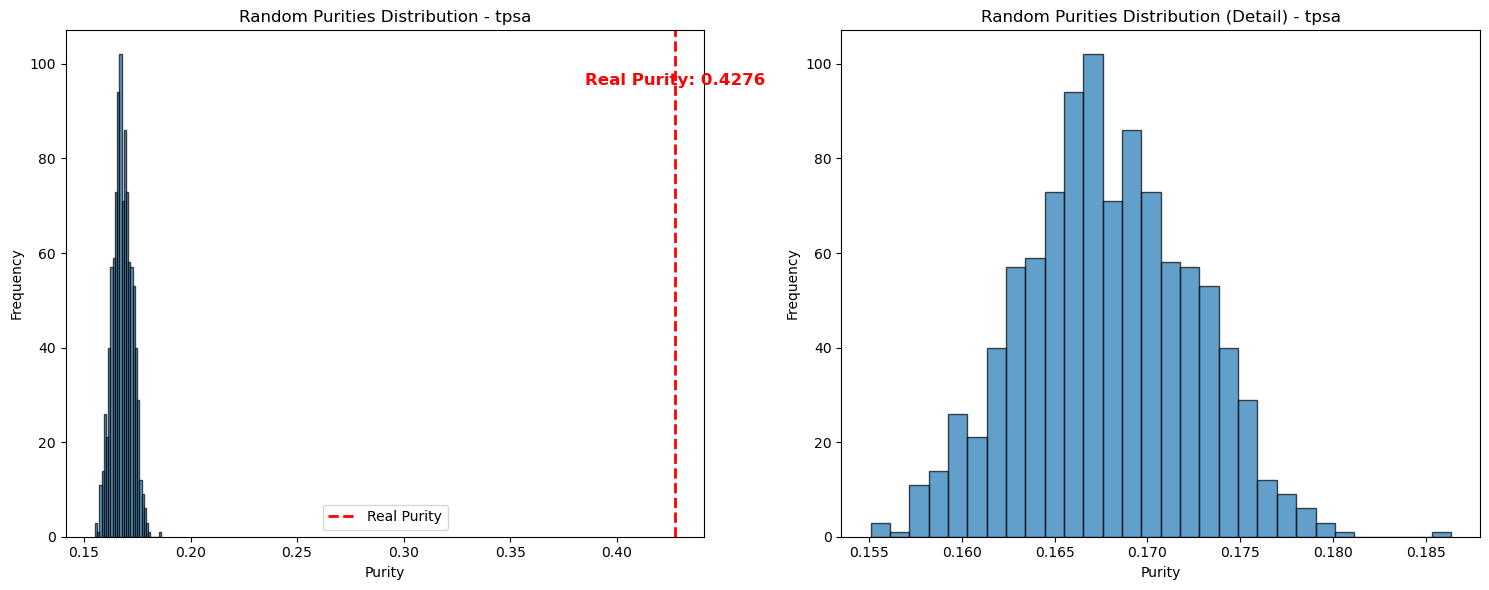

<built-in function id> 0.0 tpsa


In [263]:
labels = tpsa_label
labels = np.array(labels)
label_type = "tpsa"

lsh_purity_real = lsh_forest_purity(s, t, labels)
random_purities = []

for _ in range(num_permutations):
    shuffled_labels = np.random.permutation(labels)
    random_purity = lsh_forest_purity(s, t, shuffled_labels)
    random_purities.append(random_purity)

random_purities = np.array(random_purities)
fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 

axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Purity')
axs[0].set_title(f"Random Purities Distribution - {label_type}")
axs[0].set_xlabel("Purity")
axs[0].set_ylabel("Frequency")
axs[0].legend()
axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Purity: {lsh_purity_real:.4f}', 
            color='red', ha='center', va='center', fontsize=12, fontweight='bold')

axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
axs[1].set_title(f"Random Purities Distribution (Detail) - {label_type}")
axs[1].set_xlabel("Purity")
axs[1].set_ylabel("Frequency")

plt.tight_layout() 
plt.savefig(f"{output_dir}/random_purities_{label_type}.png")
plt.show()

p_value = np.mean(random_purities >= lsh_purity_real)
print(id, p_value, label_type)

scores.append([id, p_value, label_type])

if label_type == "3":
    p_values_3.append(p_value)
else:
    p_values_full.append(p_value)

In [264]:
smiles = df.iloc[:, 0].tolist()
mw = mol_weights
sorted_mw = sorted(mw)
sorted_mw_index = sorted(range(len(mw)), key=lambda k: mw[k])
sorted_smiles = [smiles[i] for i in sorted_mw_index]
sorted_mols = [mols[i] for i in sorted_mw_index]

In [265]:
mw_label = [0 for _ in range(len(mw))]

label = 0
index = 0

for i in count:
    index_next = index + i
    for j in range(index, index_next):
        mw_label[sorted_mw_index[j]] = label
    index = index_next
    label += 1

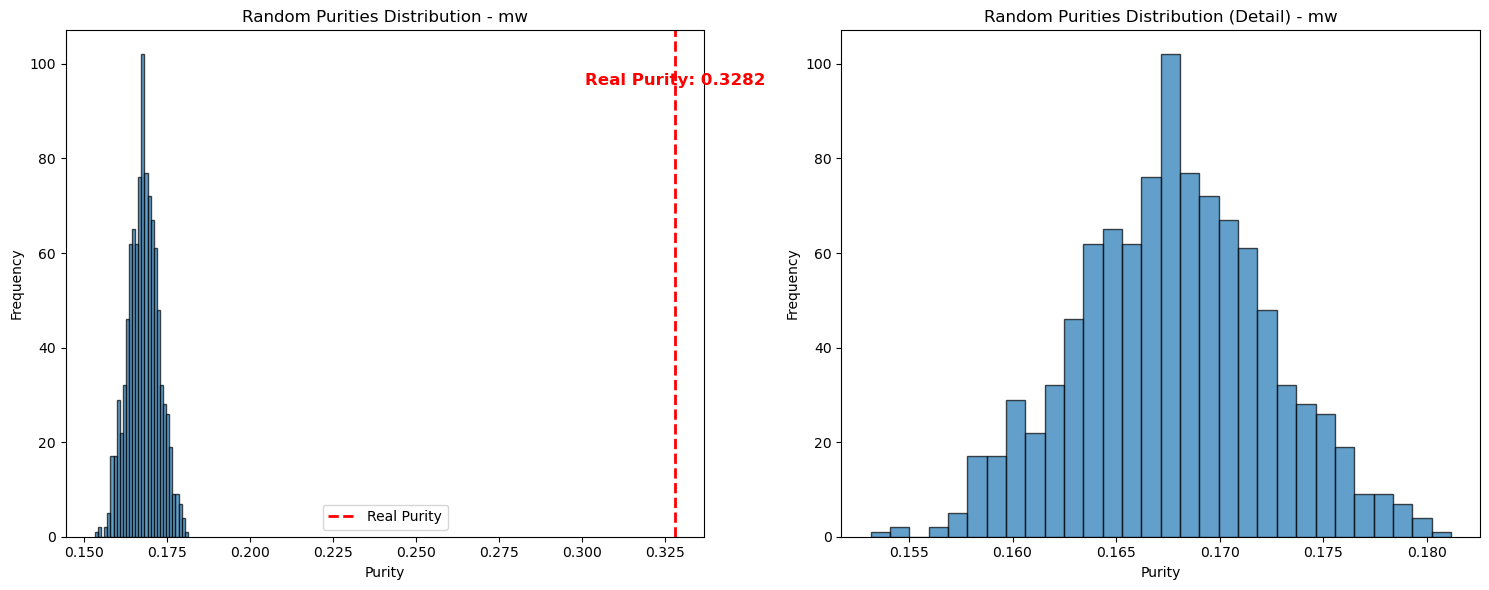

<built-in function id> 0.0 mw


In [266]:
labels = mw_label
labels = np.array(labels)
label_type = "mw"

lsh_purity_real = lsh_forest_purity(s, t, labels)
random_purities = []

for _ in range(num_permutations):
    shuffled_labels = np.random.permutation(labels)
    random_purity = lsh_forest_purity(s, t, shuffled_labels)
    random_purities.append(random_purity)

random_purities = np.array(random_purities)
fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 

axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Purity')
axs[0].set_title(f"Random Purities Distribution - {label_type}")
axs[0].set_xlabel("Purity")
axs[0].set_ylabel("Frequency")
axs[0].legend()
axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Purity: {lsh_purity_real:.4f}', 
            color='red', ha='center', va='center', fontsize=12, fontweight='bold')

axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
axs[1].set_title(f"Random Purities Distribution (Detail) - {label_type}")
axs[1].set_xlabel("Purity")
axs[1].set_ylabel("Frequency")

plt.tight_layout() 
plt.savefig(f"{output_dir}/random_purities_{label_type}.png")
plt.show()

p_value = np.mean(random_purities >= lsh_purity_real)
print(id, p_value, label_type)

scores.append([id, p_value, label_type])

if label_type == "3":
    p_values_3.append(p_value)
else:
    p_values_full.append(p_value)

In [267]:
smiles = df.iloc[:, 0].tolist()
sorted_logp = sorted(logp)
sorted_logp_index = sorted(range(len(logp)), key=lambda k: logp[k])
sorted_smiles = [smiles[i] for i in sorted_logp_index]
sorted_mols = [mols[i] for i in sorted_logp_index]

In [268]:
logp_label = [0 for _ in range(len(logp))]

label = 0
index = 0

for i in count:
    index_next = index + i
    for j in range(index, index_next):
        logp_label[sorted_logp_index[j]] = label
    index = index_next
    label += 1

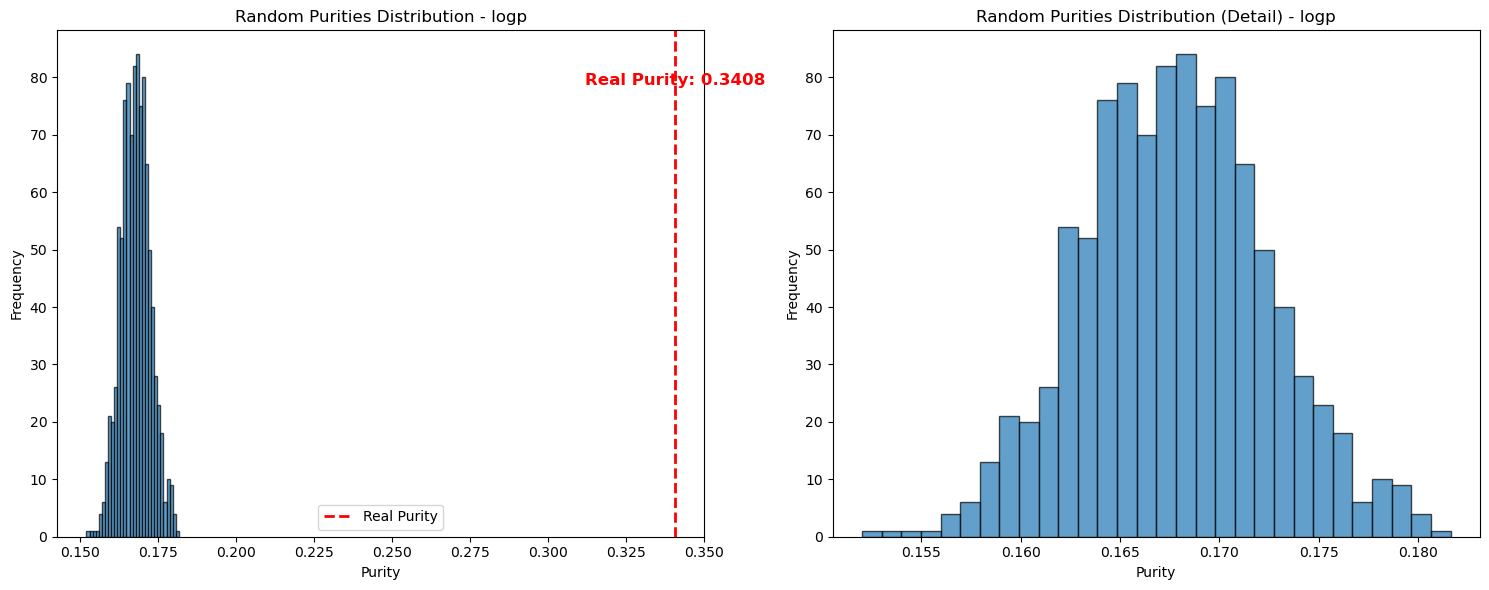

<built-in function id> 0.0 logp


In [269]:
labels = logp_label
labels = np.array(labels)
label_type = "logp"

lsh_purity_real = lsh_forest_purity(s, t, labels)
random_purities = []

for _ in range(num_permutations):
    shuffled_labels = np.random.permutation(labels)
    random_purity = lsh_forest_purity(s, t, shuffled_labels)
    random_purities.append(random_purity)

random_purities = np.array(random_purities)
fig, axs = plt.subplots(1, 2, figsize=(15, 6)) 

axs[0].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
axs[0].axvline(lsh_purity_real, color='red', linestyle='dashed', linewidth=2, label='Real Purity')
axs[0].set_title(f"Random Purities Distribution - {label_type}")
axs[0].set_xlabel("Purity")
axs[0].set_ylabel("Frequency")
axs[0].legend()
axs[0].text(lsh_purity_real, axs[0].get_ylim()[1] * 0.9, f'Real Purity: {lsh_purity_real:.4f}', 
            color='red', ha='center', va='center', fontsize=12, fontweight='bold')

axs[1].hist(random_purities, bins=30, edgecolor='black', alpha=0.7)
axs[1].set_title(f"Random Purities Distribution (Detail) - {label_type}")
axs[1].set_xlabel("Purity")
axs[1].set_ylabel("Frequency")

plt.tight_layout() 
plt.savefig(f"{output_dir}/random_purities_{label_type}.png")
plt.show()

p_value = np.mean(random_purities >= lsh_purity_real)
print(id, p_value, label_type)

scores.append([id, p_value, label_type])

if label_type == "3":
    p_values_3.append(p_value)
else:
    p_values_full.append(p_value)

In [270]:
filepaths = {
    "x": f"{output_dir}/x.pkl",
    "y": f"{output_dir}/y.pkl",
    "s": f"{output_dir}/s.pkl",
    "t": f"{output_dir}/t.pkl",
}

pickle_dump(list(x), filepaths["x"])
pickle_dump(list(y), filepaths["y"])
pickle_dump(list(s), filepaths["s"])
pickle_dump(list(t), filepaths["t"])